# 1. Instrucciones

Como saben la siguiente semana tienen el primer parcial. Estos serán en salas de computo con computadores de la universidad. Teniendo en cuenta lo anterior, no van a poder usar google colab o jupyter en anaconda porque no hay acceso, tendrán que usar Visual Studio Code. En general, todas las herramientas son muy similares, pero si no la han usado les recomendamos que sepan como usarla. Detalles a tener encuenta:

Apenas abran Visual Studio Code tienen que instalar la dependencia de Jupyter para que los notebook se puedan visualizar correctamente:
Cuando ejecuten el notebook van a tener que seleccionar un kernel, deben seleccionar Python Environments y luego seleccionar el ambiente de anaconda3.

Con el fin de que puedan resolver inquietudes de código, tendrán acceso a los siguientes sitios:
- https://scikit-learn.org/
- https://pandas.pydata.org/
- https://imbalanced-learn.org/stable/
- https://numpy.org/
- https://matplotlib.org/
- https://seaborn.pydata.org/
- https://pypi.org/

# 2. Carga y exploración del dataset

In [32]:
# Cargar las librerías necesarias
import pandas as pd

# Cargar el dataset
df = pd.read_csv('Data/Etapa1DatosEstudiantes.csv', sep=';', encoding='utf-8')

# Visualizar las primeras filas
print("Primeras filas del dataset:")
display(df.head())

# Revisar dimensiones
print("Dimensiones del dataset (filas, columnas):", df.shape)

# Tipos de variables
print("Tipos de variables:")
print(df.dtypes)

# Revisión rápida de valores nulos
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

Primeras filas del dataset:


,Id,Sexo,Edad,MiembrosFamilia,ViveConPadres,TrabajoMama,TrabajoPapa,Cuidador,TiempoDedicadoEstudioNum,ApoyoEscolar,ApoyoEscolarFamilia,QuiereEstudioUniversitario,RelacionRomantica,CalidadRelFamilia,TiempoLibre,SaleConAmigos,Ausencias,CantAlcPorSem,PromNotas
0,1,F,18.0,5.0,S,Educacion,Am@DeCasa,Ma,11.0,Si,Si,Si,Si,1.0,3.0,2.0,13.0,2.0,7.33
1,2,F,20.0,4.0,N,Otros,Otros,Papa,2.0,No,No,No,No,2.0,4.0,5.0,14.0,3.0,10.33
2,3,F,16.0,3.0,N,Educacion,Otros,Otros,5.0,No,No,No,No,3.0,3.0,2.0,8.0,4.0,12.33
3,3,F,16.0,3.0,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.33
4,4,F,14.0,1.0,S,Otros,Salud,Otros,14.0,No,Si,Si,No,1.0,2.0,3.0,19.0,3.0,14.00


Dimensiones del dataset (filas, columnas): (1161, 19)
Tipos de variables:
Id                              int64
Sexo                           object
Edad                          float64
MiembrosFamilia               float64
ViveConPadres                  object
TrabajoMama                    object
TrabajoPapa                    object
Cuidador                       object
TiempoDedicadoEstudioNum      float64
ApoyoEscolar                   object
ApoyoEscolarFamilia            object
QuiereEstudioUniversitario     object
RelacionRomantica              object
CalidadRelFamilia             float64
TiempoLibre                   float64
SaleConAmigos                 float64
Ausencias                     float64
CantAlcPorSem                 float64
PromNotas                     float64
dtype: object
Conteo de valores nulos por columna:
Id                             0
Sexo                           0
Edad                           1
MiembrosFamilia                1
ViveConPadres        

# 3. Selección de variables

In [33]:
# Mostrar columnas disponibles
print("Columnas originales:\n", df.columns.tolist())

# Decisión: Supongamos que solo nos interesan análisis de películas, duración, género y país
columnas_a_mantener = ['Id','Sexo', 'Edad', 'ViveConPadres', 'TiempoDedicadoEstudioNum', 'ApoyoEscolar',
                       'QuiereEstudioUniversitario', 'RelacionRomantica', 'CalidadRelFamilia',
                       'TiempoLibre', 'SaleConAmigos', 'Ausencias', 'PromNotas']
columnas_a_usar = [c for c in columnas_a_mantener if c in df.columns]

df_reducido = df[columnas_a_usar].copy()

df = df_reducido.copy()


print("Columnas seleccionadas para el análisis:")
print(df_reducido.columns.tolist())

Columnas originales:
 ['Id', 'Sexo', 'Edad', 'MiembrosFamilia', 'ViveConPadres', 'TrabajoMama', 'TrabajoPapa', 'Cuidador', 'TiempoDedicadoEstudioNum', 'ApoyoEscolar', 'ApoyoEscolarFamilia', 'QuiereEstudioUniversitario', 'RelacionRomantica', 'CalidadRelFamilia', 'TiempoLibre', 'SaleConAmigos', 'Ausencias', 'CantAlcPorSem', 'PromNotas']
Columnas seleccionadas para el análisis:
['Id', 'Sexo', 'Edad', 'ViveConPadres', 'TiempoDedicadoEstudioNum', 'ApoyoEscolar', 'QuiereEstudioUniversitario', 'RelacionRomantica', 'CalidadRelFamilia', 'TiempoLibre', 'SaleConAmigos', 'Ausencias', 'PromNotas']


In [34]:
df['TiempoLibre'].value_counts()


TiempoLibre
 3.0      369
 4.0      276
 2.0      215
 5.0      151
 1.0      143
 300.0      2
-3.0        1
 100.0      1
 200.0      1
Name: count, dtype: int64

# 4. Preparación de los datos

In [42]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Completitud y Unicidad
print("Valores nulos por columna:\n", df.isnull().sum())
print(f"Filas duplicadas: {df.duplicated().sum()}")
df = df.dropna(subset=['Id','Sexo', 'Edad', 'ViveConPadres', 'TiempoDedicadoEstudioNum', 'ApoyoEscolar',
                       'QuiereEstudioUniversitario', 'RelacionRomantica', 'CalidadRelFamilia',
                       'TiempoLibre', 'SaleConAmigos', 'Ausencias', 'PromNotas'])
df = df.drop_duplicates()

# Eliminación de columnas irrelevantes
columnas_a_eliminar = ['Id']
df = df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns])

# Consistencia y validez
if 'Edad' in df.columns:
    print(f"Rango Edad: {df['Edad'].min()} - {df['Edad'].max()}")

if 'Ausencias' in df.columns:
    print(f"Rango Ausencias: {df['Ausencias'].min()} - {df['Ausencias'].max()}")

if 'CantAlcPorSem' in df.columns:
    print(f"Rango CantAlcPorSem: {df['CantAlcPorSem'].min()} - {df['CantAlcPorSem'].max()}")

if 'PromNotas' in df.columns:
    print(f"Rango PromNotas: {df['PromNotas'].min()} - {df['PromNotas'].max()}")
    


# Codificación de variables categóricas clave
cols_texto = ['Sexo',
'ViveConPadres',
'TrabajoMama',
'TrabajoPapa',
'Cuidador',
'ApoyoEscolar',
'ApoyoEscolarFamilia',
'QuiereEstudioUniversitario',
'RelacionRomantica']

for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].str.strip().str.capitalize()

# Verificar que quedaron bien
for col in cols_texto:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")
        
# Codificación de variables categóricas clave
cat_cols_clave = ['Sexo',
'ViveConPadres',
'TrabajoMama',
'TrabajoPapa',
'Cuidador',
'ApoyoEscolar',
'ApoyoEscolarFamilia',
'QuiereEstudioUniversitario',
'RelacionRomantica']

for col in cat_cols_clave:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(columns=[col])

print("Columnas tras codificación:", df.columns.tolist())


# --- Normalización y estandarización ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df["TiempoLibre"] = df["TiempoLibre"].replace({
    300: 3,
    -3: 3,
    100: 1,
    200: 2
})

# separar continuas de binarias (para no escalar dummies)
def es_binaria(serie):
    vals = serie.dropna().unique()
    return len(vals) <= 2

cont_cols = [c for c in num_cols if not es_binaria(df[c])]

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df_minmax = df.copy()
if cont_cols:
    df_minmax[cont_cols] = scaler_minmax.fit_transform(df_minmax[cont_cols])
print("\nVariables numéricas normalizadas (MinMax):")
print(df_minmax[cont_cols].head())

df_std = df.copy()
if cont_cols:
    df_std[cont_cols] = scaler_std.fit_transform(df_std[cont_cols])
print("\nVariables numéricas estandarizadas (StandardScaler):")
print(df_std[cont_cols].head())

# Matriz de correlación para selección de variables
import seaborn as sns
import matplotlib.pyplot as plt
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

if 'PromNotas' in corr.columns:
    high_corr = corr['PromNotas'].abs().sort_values(ascending=False)
    print("\nVariables numéricas con mayor correlación con PromNotas:")
    print(high_corr[1:])

#Métodos adicionales

df = df.replace(r'^\s*$', np.nan, regex=True)



df.to_excel('Exoplanets_dataset_2.xlsx', index=False)

df = df.drop(columns=['columna_a_eliminar'])

df['variable'] = df['variable'].astype('Int64')
df['variable_otrodato'] = pd.to_numeric(df['variable_pasaraint'], errors='coerce')

df["va_datos_cortar"] = df["va_datos_cortar"].str[-3:]

#imputar media o mediana
variable_median = df['variable'].median()
df['variable'] = df['variable'].fillna(variable_median)

#filtros 
df = df[df["variable"] > 0]
df = df[(df["variable_en_intervalo"] > 0) & (df["variable_en_intervalo"] < 360)]

#agrupar datos y sacar maximo 
maxfila = df.groupby('variable')["criterio"].idxmax()
data_train = df.loc[maxfila]

#variables categoricas
df["cumplircondicion_cambiarlo_categoria"] = np.where(df["numero_estrellas_sis"] == 2, "Sí", df["binario_sis"])
df.loc[df["cumplircondicion_cambiarlo_categoria"] == 2, "binario_sis"] = "Sí"


Valores nulos por columna:
 Edad                             0
TiempoDedicadoEstudioNum         0
CalidadRelFamilia                0
TiempoLibre                      0
SaleConAmigos                    0
Ausencias                        0
PromNotas                        0
Sexo_M                           0
ViveConPadres_S                  0
ApoyoEscolar_Si                  0
QuiereEstudioUniversitario_Si    0
RelacionRomantica_Si             0
dtype: int64
Filas duplicadas: 0


KeyError: ['Id', 'Sexo', 'ViveConPadres', 'ApoyoEscolar', 'QuiereEstudioUniversitario', 'RelacionRomantica']

In [ ]:
df_std

# 5. Análisis exploratorio de datos (EDA)

---- .info() ----
<class 'pandas.core.frame.DataFrame'>
Index: 1125 entries, 0 to 1160
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Edad                           1125 non-null   float64
 1   TiempoDedicadoEstudioNum       1125 non-null   float64
 2   CalidadRelFamilia              1125 non-null   float64
 3   TiempoLibre                    1125 non-null   float64
 4   SaleConAmigos                  1125 non-null   float64
 5   Ausencias                      1125 non-null   float64
 6   PromNotas                      1125 non-null   float64
 7   Sexo_M                         1125 non-null   bool   
 8   ViveConPadres_S                1125 non-null   bool   
 9   ApoyoEscolar_Si                1125 non-null   bool   
 10  QuiereEstudioUniversitario_Si  1125 non-null   bool   
 11  RelacionRomantica_Si           1125 non-null   bool   
dtypes: bool(5), float64(7)
memory usage

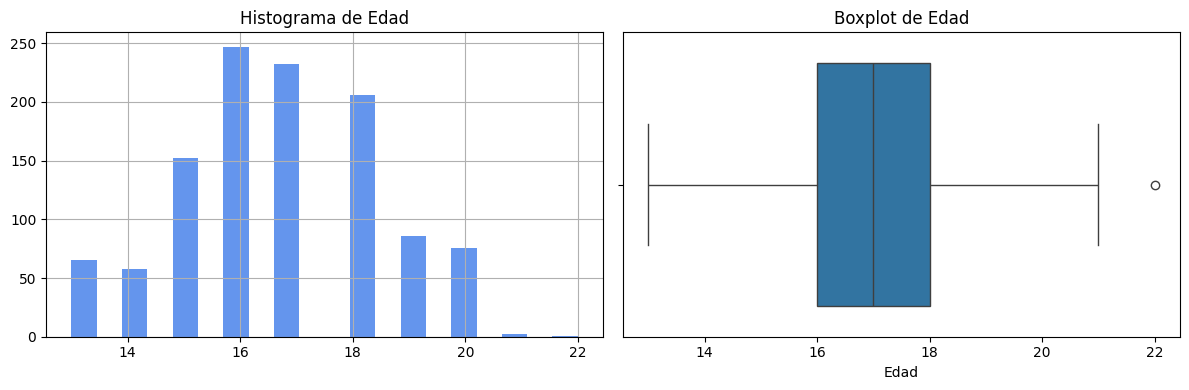

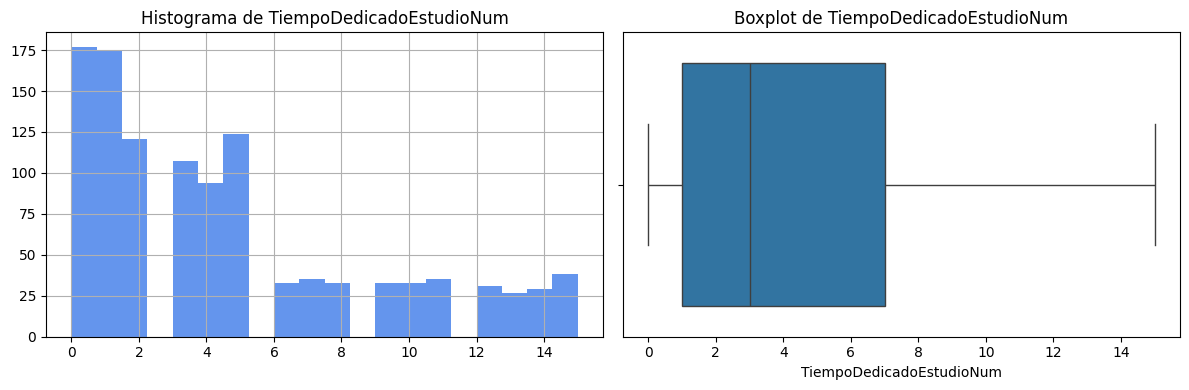

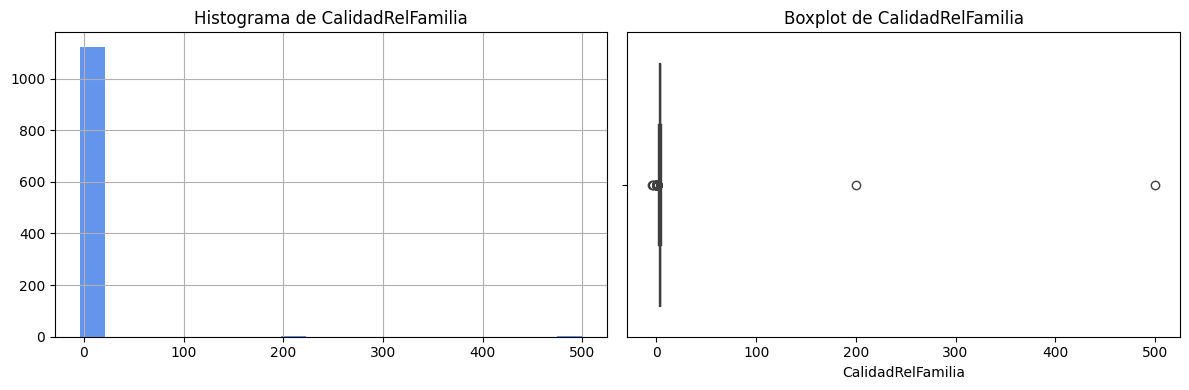

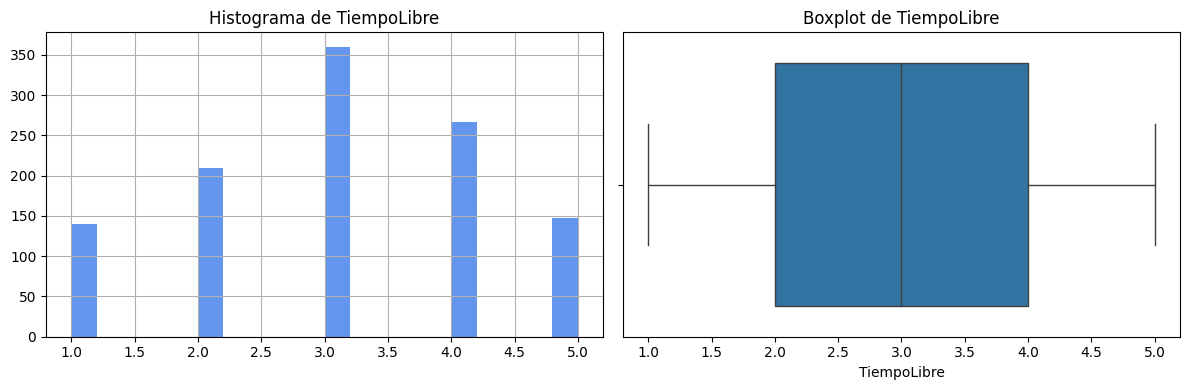

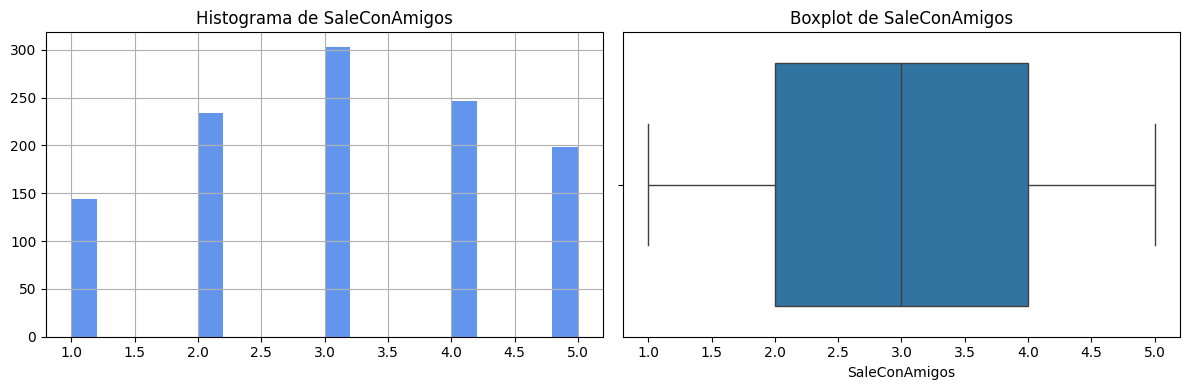

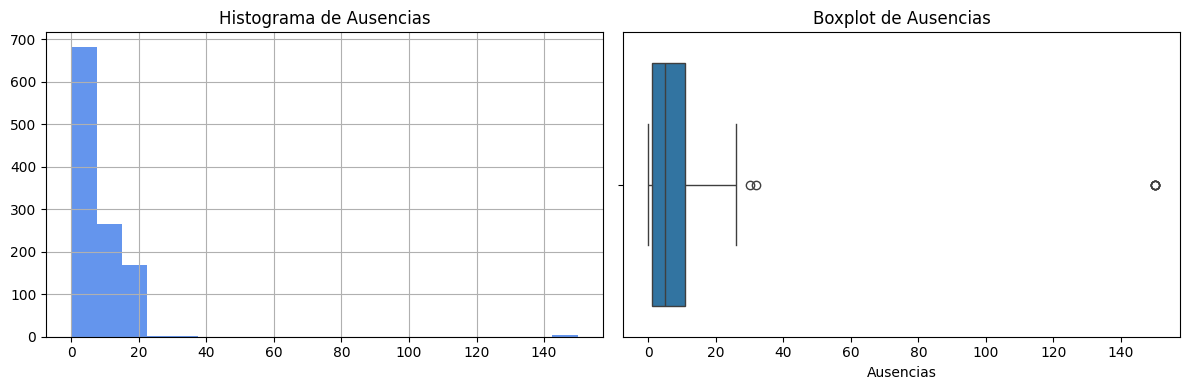

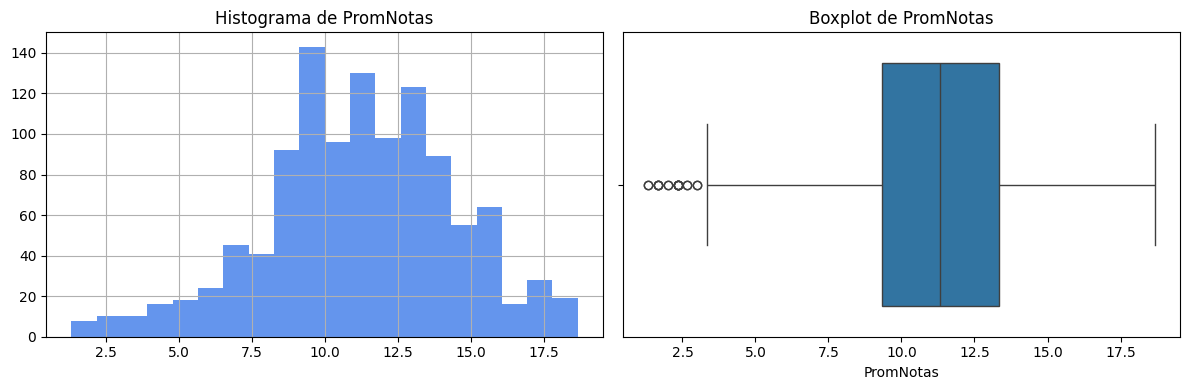

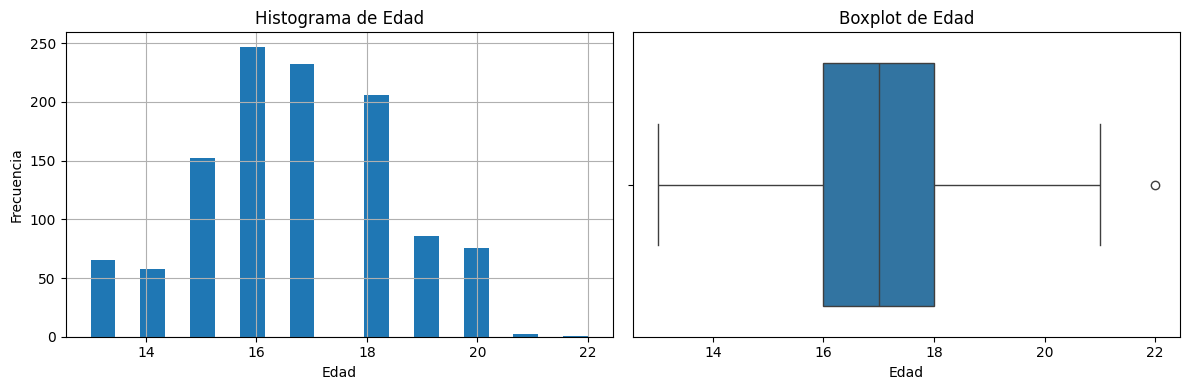

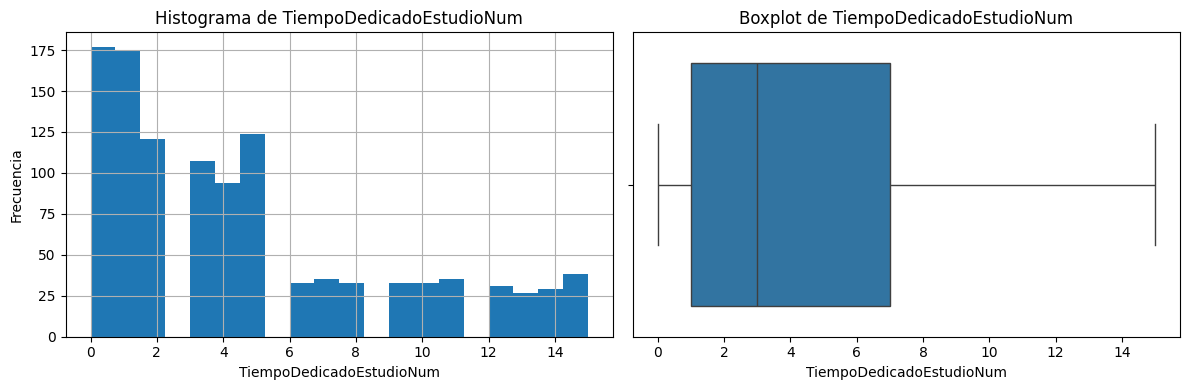

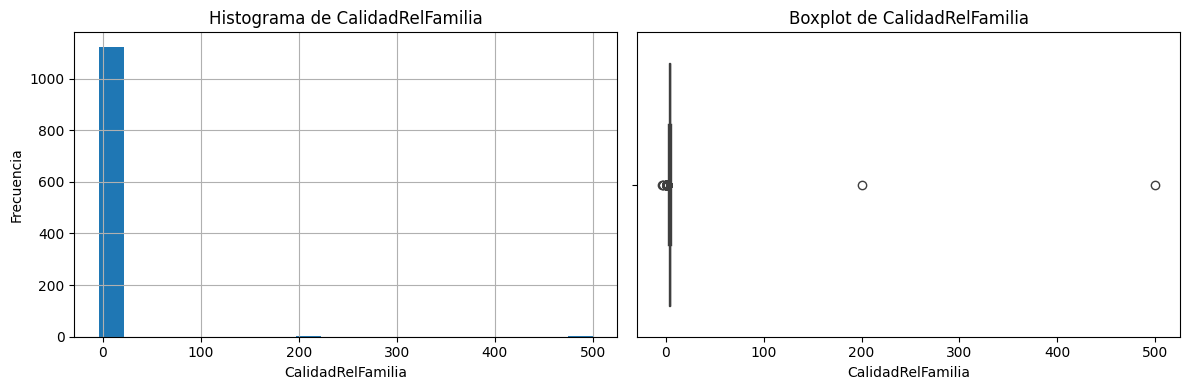

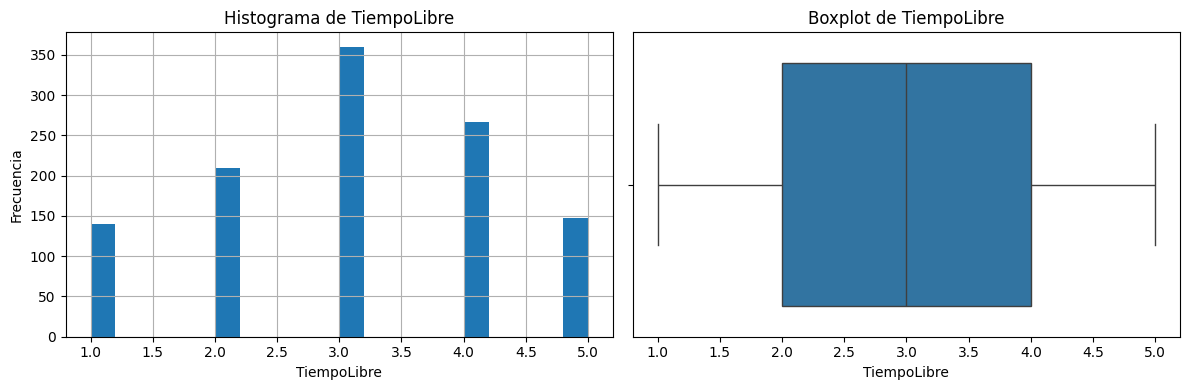

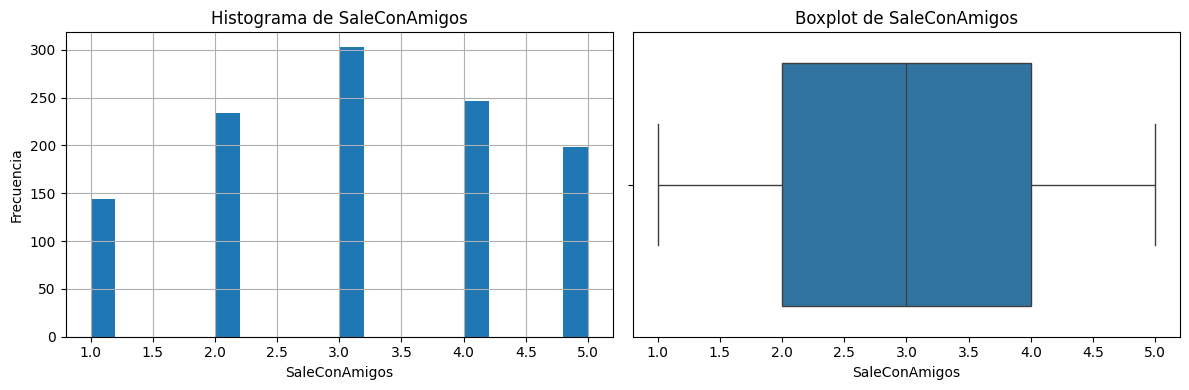

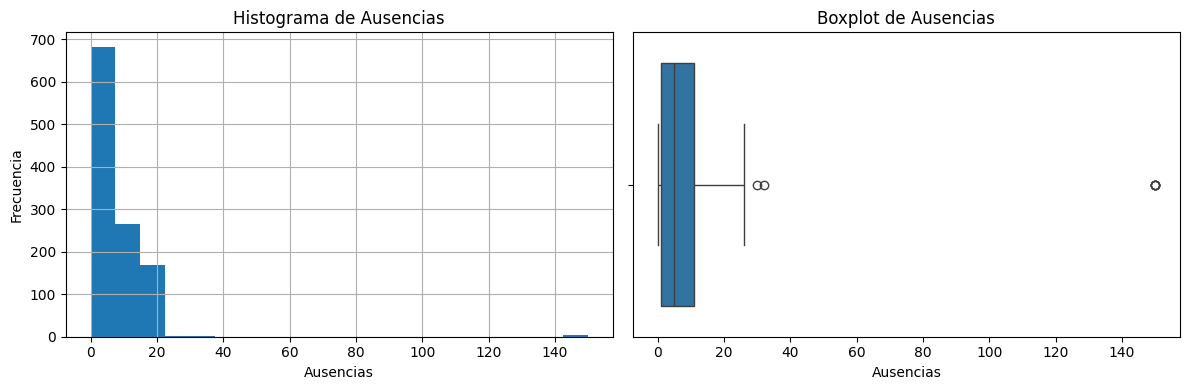

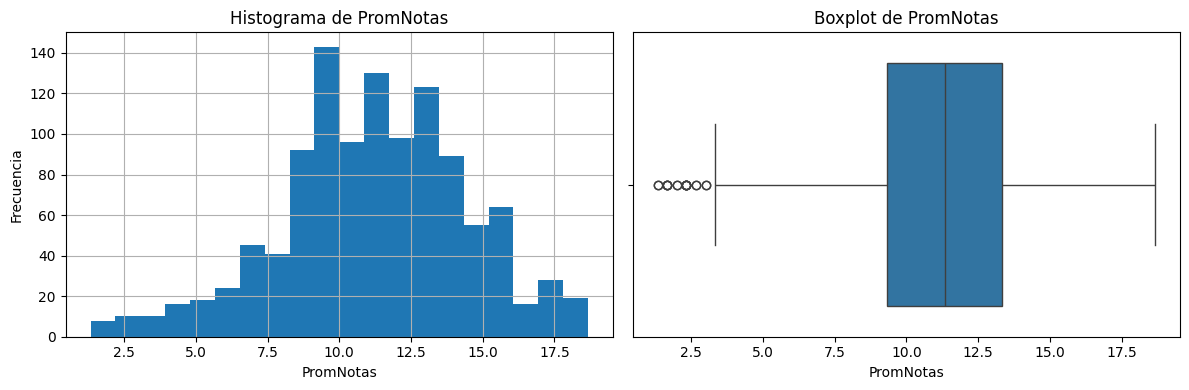

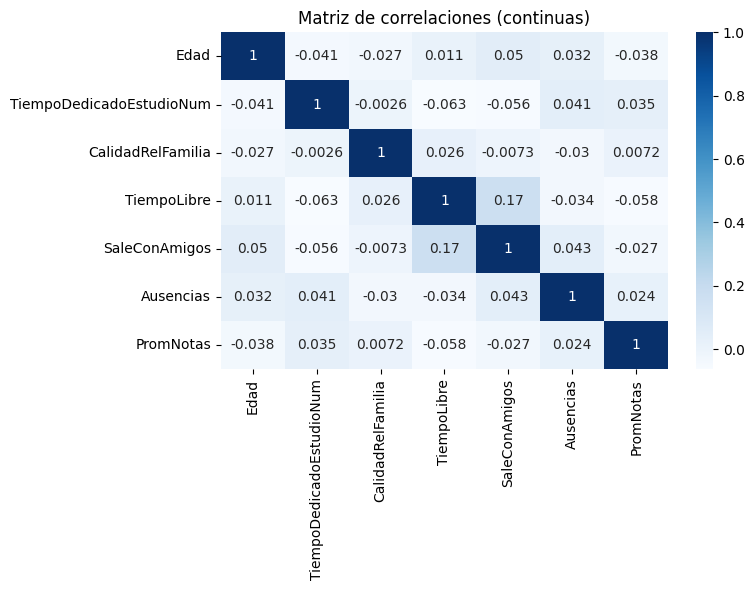

In [43]:
# Estructura y estadísticos básicos
print("---- .info() ----")
print(df.info())
print("\n---- .describe() ----")
print(df.describe(include='all'))

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    for col in cat_cols:
        print(f"\n---- value_counts() para '{col}' (top 20) ----")
        print(df[col].value_counts(dropna=False).head(20))

# Histogramas y boxplots para variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    df[col].dropna().hist(ax=axes[0], bins=20, color='cornflowerblue')
    axes[0].set_title(f"Histograma de {col}")
    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

# ====== Histogramas y boxplots para numéricas continuas ======
for col in cont_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    df[col].dropna().hist(ax=axes[0], bins=20)
    axes[0].set_title(f"Histograma de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

# Histogramas/barplots para variables categóricas principales
if cat_cols:
    for col in cat_cols:
        if df[col].nunique() <= 20:
            plt.figure(figsize=(8,3))
            df[col].value_counts().plot(kind='bar')
            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()

# Matriz de correlación
if len(cont_cols) > 1:
    corr = df[cont_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='Blues')
    plt.title("Matriz de correlaciones (continuas)")
    plt.tight_layout()
    plt.show()

# ====== Scatterplot respecto a variable objetivo ======
if 'Imdb_Score' in df.columns and 'Duration_min' in df.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x='Duration_min', y='Imdb_Score', alpha=0.7)
    plt.title("Duración vs IMDB Score")
    plt.xlabel("Duración (minutos)")
    plt.ylabel("IMDB Score")
    plt.tight_layout()
    plt.show()

# 6. Modelos y métricas

MAE: 0.7098496996079701
RMSE: 0.9253831305265162
R^2: -0.00287311971987525
Coeficiente para TiempoDedicadoEstudioNum: 0.0069
Coeficiente para CalidadRelFamilia: 0.0094
Coeficiente para TiempoLibre: 0.0350
Coeficiente para Ausencias: 0.0221
Intercepto: -0.0197


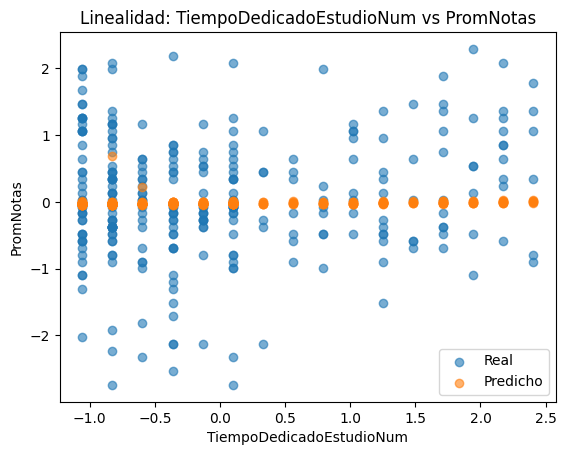

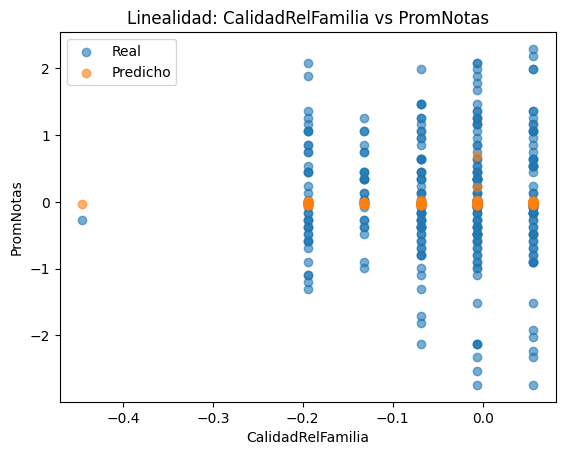

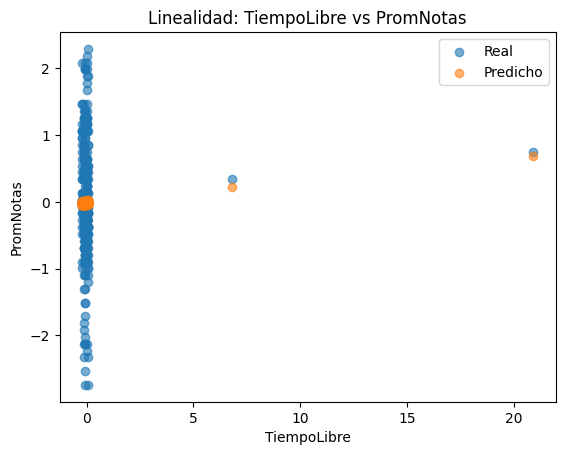

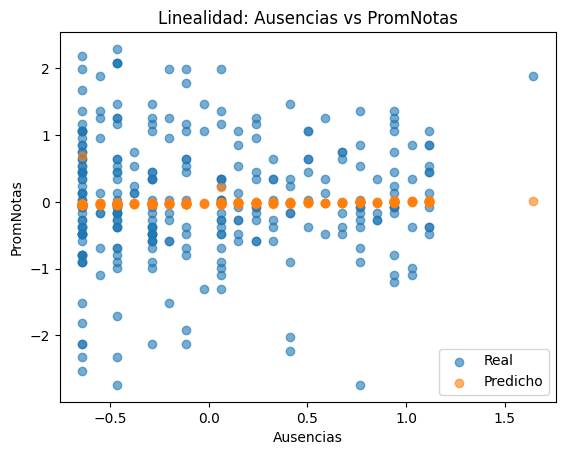

In [44]:
# === REGRESIÓN ===
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

features = ['TiempoDedicadoEstudioNum', 'CalidadRelFamilia', 'TiempoLibre', 'Ausencias']
target = 'PromNotas'
X = df_std[features].dropna()
y = df_std.loc[X.index, target]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
# Coeficientes
for i, col in enumerate(features):
    print(f"Coeficiente para {col}: {model.coef_[i]:.4f}")
print(f"Intercepto: {model.intercept_:.4f}")
# Linealidad
for col in features:
    plt.figure()
    plt.scatter(X_test[col], y_test, label='Real', alpha=0.6)
    plt.scatter(X_test[col], y_pred, label='Predicho', alpha=0.6)
    plt.title(f"Linealidad: {col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.legend()
    plt.show()


In [ ]:
# === CLASIFICACIÓN ===
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

feature_cols = [
    c for c in df_std.columns
    if c not in ['Imdb_Score', 'Content Type']  # excluye explícitamente target
    and not c.startswith('Content Type')                      # excluye cualquier dummy prefijada
]
X = df_std[feature_cols]
y = df_std['Content Type']

print("Variables predictoras:\n", X.columns.tolist())

# Balance de clases
counts = pd.Series(y).value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("Balance de clases")
plt.show()
# Grupos naturales
print("Ejemplo de 'Content Type':", y.unique())


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grids = [
    (
        DecisionTreeClassifier(random_state=42), "Decision Tree",
        {"max_depth":[None,3,5,10], "min_samples_split":[2,5,10], "min_samples_leaf":[1,2,5]}
    ),
    (
        RandomForestClassifier(random_state=42), "Random Forest",
        {"n_estimators":[100,300], "max_depth":[None,10,20], "max_features":["sqrt","log2"]}
    ),
    (
        KNeighborsClassifier(), "K Neighbors",
        {"n_neighbors":[3,5,9,15], "weights":["uniform","distance"], "p":[1,2]}
    ),
]

for est, name, param_grid in grids:
    print(f"\n------ {name} (GridSearchCV) ------")
    gs = GridSearchCV(est, param_grid, scoring="accuracy", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    print("Mejores params:", gs.best_params_)
    print("CV best score (acc):", gs.best_score_)
    y_pred = best.predict(X_test)
    print("Accuracy test:", accuracy_score(y_test, y_pred))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
    if hasattr(best, "feature_importances_"):
        importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        print("Top-10 importancias:\n", importances)
    if isinstance(best, DecisionTreeClassifier):
        plt.figure(figsize=(10,5))
        plot_tree(best, feature_names=X.columns, class_names=best.classes_, filled=True, max_depth=2)
        plt.show()

# ========================================================================
# BALANCEO DE CLASES CON SMOTE
# ========================================================================

from sklearn.utils import resample
from collections import Counter

# Distribución original
print('Distribución de clases antes de oversampling:', Counter(y_train))

# Combinar X_train e y_train
train = X_train.copy()
train['target'] = y_train

# Separar clases
clases = train['target'].unique()
mayoritaria = train['target'].value_counts().idxmax()
minoritaria = train['target'].value_counts().idxmin()

df_may = train[train['target'] == mayoritaria]
df_min = train[train['target'] == minoritaria]

# Oversampling de la clase minoritaria
df_min_over = resample(
    df_min,
    replace=True,                 # muestreo con reemplazo
    n_samples=len(df_may),        # igualar a la clase mayoritaria
    random_state=42
)

# Nuevo dataset balanceado
train_bal = pd.concat([df_may, df_min_over])

X_train_bal = train_bal.drop(columns=['target'])
y_train_bal = train_bal['target']

print('Distribución de clases después de oversampling:', Counter(y_train_bal))


In [ ]:
# === CLUSTERING (KMeans con 2 features) ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

clust_features = ['Imdb_Score', 'Duration_min']  # 2 variables
X = df[clust_features].dropna().copy()

# 1) Escalado: guarda el scaler para invertir luego
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Curva de elbow
sse = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)
plt.figure()
plt.plot(k_range, sse, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia (SSE)')
plt.title('Curva de Elbow para KMeans')
plt.tight_layout()
plt.show()

# 3) Validación cruzada con silueta
opt_k = 3
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sils = []
for train_idx, test_idx in kf.split(X_scaled):
    model = KMeans(n_clusters=opt_k, random_state=42).fit(X_scaled[train_idx])
    preds = model.predict(X_scaled[test_idx])
    sils.append(silhouette_score(X_scaled[test_idx], preds))
print(f"Silhouette promedio (KFold, k={opt_k}): {np.mean(sils):.3f}")

# 4) Agrupamiento final
kmeans = KMeans(n_clusters=opt_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 5) Pega clusters a datos en escala ORIGINAL para graficar e interpretar
X_plot = X.copy()
X_plot['Cluster'] = clusters
print(X_plot['Cluster'].value_counts())

# 6) Pairplot (opcional)
sns.pairplot(X_plot, hue="Cluster", palette="tab10")
plt.suptitle("Comportamiento en parejas de atributos por cluster")
plt.tight_layout()
plt.show()

# 7) Centroides: conviértelos a escala ORIGINAL
centers_scaled = kmeans.cluster_centers_                  # (k, 2) en escala estandarizada
centers_orig = scaler.inverse_transform(centers_scaled)   # back a unidades originales
centroides_originales = pd.DataFrame(centers_orig, columns=clust_features)
print('Centroides en unidades originales:')
print(centroides_originales)

# 8) Visualización 2D en unidades originales + centroides
plt.figure(figsize=(8,6))
for i in range(opt_k):
    plt.scatter(
        X_plot.loc[X_plot["Cluster"]==i, 'Imdb_Score'],
        X_plot.loc[X_plot["Cluster"]==i, 'Duration_min'],
        label=f'Cluster {i}', alpha=0.7
    )
plt.scatter(
    centroides_originales['Imdb_Score'],
    centroides_originales['Duration_min'],
    s=200, c='black', marker='X', label='Centroides'
)
plt.xlabel('Imdb_Score')
plt.ylabel('Duration_min')
plt.title('Clusters y centroides (escala original)')
plt.legend()
plt.tight_layout()
plt.show()

# 9) Siluetas
cluster_labels = kmeans.labels_
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(opt_k):
    ith = silhouette_vals[cluster_labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Promedio: {silhouette_avg:.2f}")
plt.xlabel("Valor de la silueta")
plt.ylabel("Cluster")
plt.title("Visualización de siluetas para cada cluster")
plt.tight_layout()
plt.show()


# 7. Pipeline

En esta sección construimos pipelines que integran todo el flujo de preprocesamiento (incluyendo limpieza total) y modelado, usando un transformer personalizado.

In [ ]:
# =======================
# PIPELINE (usa tus add-features existentes)
# =======================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 1) Definir target y columnas de entrada desde TU df ya preprocesado ---
assert 'Imdb_Score' in df.columns, "Falta Imdb_Score (asegura el paso de extracción previo)."

y = df['Imdb_Score']

# Columnas numéricas continuas disponibles
num_features = [c for c in ['Duration_min', 'Seasons'] if c in df.columns]

# Dummies ya creadas por ti (géneros, rating, país, etc.)
dummy_features = [c for c in df.columns if c.startswith('Genre_') or c.startswith('Rating_') 
                  or c.startswith('Production Country_') or c.startswith('Content Type_')]

# Evita meter columnas crudas/texto y el propio target
cols_excluir = set(['Imdb_Score', 'Imdb Score', 'Duration', 'Title', 'Director', 'Cast'])
feature_cols = [c for c in (num_features + dummy_features) if c not in cols_excluir]

X = df[feature_cols].copy()

# --- 2) Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# --- 3) Preprocesamiento: escalar SOLO numéricas; el resto passthrough ---
preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
    ],
    remainder='passthrough'  # deja dummies tal cual
)

# --- 4) Modelo + GridSearch ---
model = Ridge(random_state=42)
param_grid = {'reg__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

pipe = Pipeline(steps=[
    ('prep', preproc),
    ('reg', model)
])

gs = GridSearchCV(pipe, param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

best = gs.best_estimator_
y_pred = best.predict(X_test)

print(f"Mejores params: {gs.best_params_}")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R^2:", r2_score(y_test, y_pred))


# 8. Supuestos y transformaciones complementarias

En esta sección verifica los supuestos del modelo (linealidad, normalidad de residuos, homocedasticidad, independencia) y aplica transformaciones (log, BoxCox, sqrt, etc.) si es necesario. Aplica ejemplos de chequeo a reg, clasif. y cluster.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# Extrae y transforma los datos
df['Imdb_Score'] = df['Imdb Score'].str.extract(r'([\d\.]+)').astype(float)
df['Duration_min'] = df['Duration'].str.extract(r'(\d+)').astype(float)
X_orig = df[['Duration_min']].dropna()
y_orig = df.loc[X_orig.index, 'Imdb_Score']

# Función para analizar supuestos y mostrar gráficos/resultados
def analizar_supuestos(X, y, descripcion="Original"):
    modelo = LinearRegression().fit(X, y)
    y_pred = modelo.predict(X)
    residuos = y - y_pred

    print(f"--- Supuestos ({descripcion}) ---")
    # Linealidad
    plt.scatter(y_pred, residuos)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicción")
    plt.ylabel("Residuos")
    plt.title(f"Linealidad (pred vs residuos) | {descripcion}")
    plt.show()
    # Normalidad
    sns.histplot(residuos, kde=True)
    plt.title(f"Histograma de residuos (Normalidad) | {descripcion}")
    plt.show()
    print(f"Media de residuos: {residuos.mean():.4f}")
    print(f"Desviación estándar de residuos: {residuos.std():.4f}")
    # Homocedasticidad visual y por varianzas
    plt.scatter(y_pred, residuos)
    plt.xlabel('Predicción')
    plt.ylabel('Residuos')
    plt.title(f"Homocedasticidad | {descripcion}")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()
    mediana_pred = np.median(y_pred)
    var_bajo = residuos[y_pred <= mediana_pred].var()
    var_alto = residuos[y_pred > mediana_pred].var()
    print(f"Varianza residuos predicción baja: {var_bajo:.4f}")
    print(f"Varianza residuos predicción alta: {var_alto:.4f}")
    # Independencia: autocorrelación lag-1
    def autocorrelacion_lag1(x):
        if len(x) < 2:
            return np.nan
        return np.corrcoef(x[:-1], x[1:])[0,1]
    autocorr = autocorrelacion_lag1(residuos.values)
    print(f"Autocorrelación lag-1 residuos: {autocorr:.4f}")
    print('\n')

# --- Análisis original ---
analizar_supuestos(X_orig, y_orig, descripcion="Original")

# --- Transformaciones complementarias ---
# 1. Logarítmica (solo si todos los valores son positivos)
if (X_orig['Duration_min']>0).all():
    X_log = np.log1p(X_orig[['Duration_min']])
    print(">>> Analizando transformación logarítmica sobre X (Duration_min):")
    analizar_supuestos(X_log, y_orig, descripcion="Duration_log")

# 2. Raíz cuadrada
if (X_orig['Duration_min']>=0).all():
    X_sqrt = np.sqrt(X_orig[['Duration_min']])
    print(">>> Analizando transformación sqrt sobre X (Duration_min):")
    analizar_supuestos(X_sqrt, y_orig, descripcion="Duration_sqrt")

# 3. Transformación sobre y (por ejemplo, logarítmica si todos los y>0)
if (y_orig>0).all():
    y_log = np.log1p(y_orig)
    print(">>> Analizando transformación logarítmica sobre y (Imdb_Score):")
    analizar_supuestos(X_orig, y_log, descripcion="Y_log")

# Ejemplo visual final de la transformación seleccionada
df['Duration_log'] = np.log1p(df['Duration_min'])
sns.histplot(df['Duration_log'].dropna(), kde=True)
plt.title("Distribución (histograma) de Duration_min transformada a log")
plt.show()